In [1]:
#Loads scripts, libraries, etc.
print('Hello, lets get started')
%matplotlib widget
import importlib
import PyMca5
import os
from analyze_sgm_bsky_data import analyze_sgm_bsky_data
from alignment_utils import interactive_roll_align
from stitching_utils import stitch_quadrant_maps
from alignment_utils import visualize_stitching_overlap
from stitching_utils import interactive_stitching_trim
from sum_mcc1_spectra import sum_mcc1_spectra
from save_pymca_stack_h5 import save_pymca_stack_h5
from plot_sgm_bsky_data import plot_sgm_bsky_data
from pca_xanes_analysis import pca_xanes_analysis
from interactive_cluster_merger import interactive_cluster_merger
from pca_xanes_analysis import run_pca_all_detectors
from cluster_xanes_analysis import run_clustering_all_detectors
from save_pymca_4d_stack_h5 import save_pymca_4d_stack_h5
from pca_stack_analysis import pca_stack_analysis
from cluster_pca_spectra import cluster_pca_spectra
from pca_xanes_analysis import pca_xanes_analysis
from cluster_xanes_analysis import cluster_xanes_analysis
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
os.environ["OMP_NUM_THREADS"] = "2"

print('Done loading libraries')

Hello, lets get started

[VERSION] Dashboard Engine v2.5 (ROI FIXED)

Done loading libraries


Please select 4 HDF5 quadrant files...
  -> Selected SW (South-West): Trial1-Tan4T-SW_map_2026-05-07_095323_0.00eV.h5
  -> Selected SE (South-East): Trial1-Tan4T-SE_map_2026-05-07_100854_0.00eV.h5
  -> Selected NE (North-East): Trial1-Tan4T-NE_map_2026-05-07_102424_0.00eV.h5
  -> Selected NW (North-West): Trial1-Tan4T-NW_map_2026-05-07_103955_0.00eV.h5


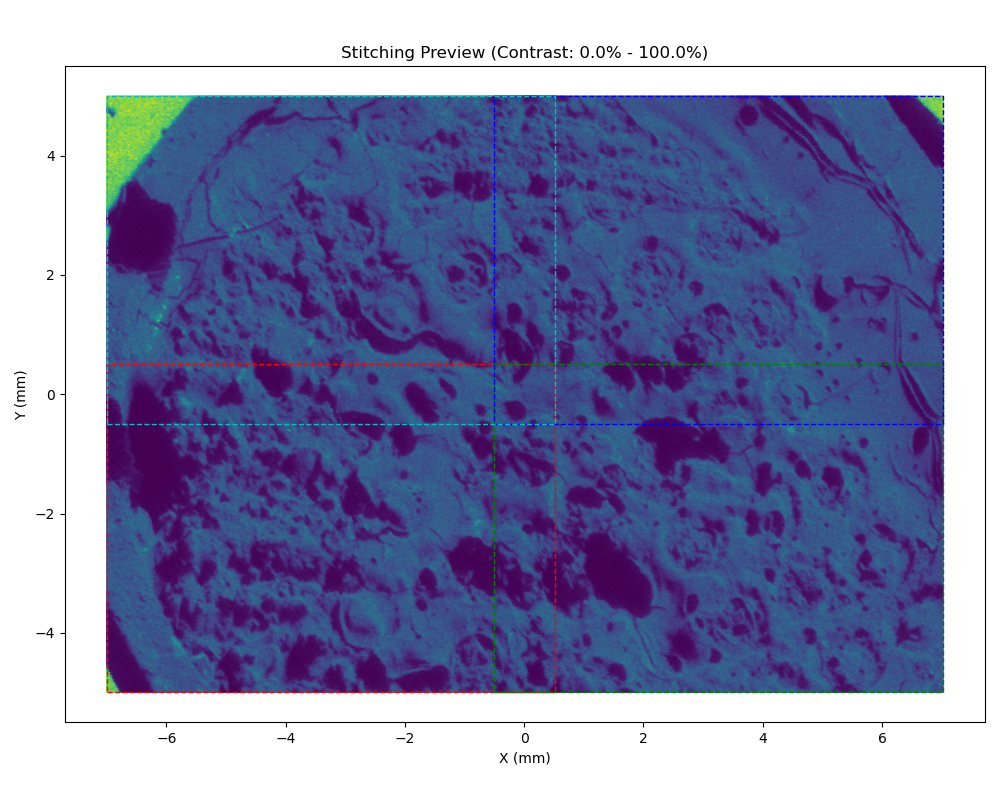

In [2]:
stitched_h5=interactive_stitching_trim()

In [3]:
sgm_data = analyze_sgm_bsky_data(stitched_h5)


Analyzing File: D:\Data\Testing_jupyter-python-axis2000\4-quadrant_maps\stitched\Stitched_Trial1-Tan4T-SW_map.h5

--- Scan Analysis Summary ---
Energies (1 points): [0.]
Number of Images:      1
Energy Regions:        0.00: 0.0 eV
X array (shape):       (363608,) (Nx: 562)
Y array (shape):       (363608,) (Ny: 602)
Grid Dimensions:       562 x 602
----------------------------
Date:                  1778169203.2995694
Scan Name:             Trial1-Tan4T-SW_map
Project:               39M14239
Beamline:              sgm_ambxas
Polarization:          N/A
Grating:               N/A
Harmonic:              N/A
Strip:                 N/A
Command:               N/A
Coordinates:           X: -7.00 to 7.03, Y: -5.00 to 5.00
Exit Slit Gap:         N/A

MCC Files Found:       1

SDD Files Found:
  Detector sdd1: 1 files
  Detector sdd2: 1 files
  Detector sdd3: 1 files
  Detector sdd4: 1 files
-----------------------------------


In [2]:
# Loads either a stack or map, including survey maps for analysis
# Browse to the file
# Summary of the stack shown in console
sgm_data = analyze_sgm_bsky_data()


Analyzing File: D:\Data\Testing_jupyter-python-axis2000\4-quadrant_maps\095323_Trial1-Tan4T-SW_map\Trial1-Tan4T-SW_map_2026-05-07_095323_0.00eV.h5
  [Fallback] Extracted energy 0.00 eV from filename.

--- Scan Analysis Summary ---
Energies (1 points): [0.]
Number of Images:      1
Energy Regions:        0.00: 0.0 eV
X array (shape):       (90902,) (Nx: 302)
Y array (shape):       (90902,) (Ny: 301)
Grid Dimensions:       302 x 301
----------------------------
Date:                  1778169203.2995694
Scan Name:             Trial1-Tan4T-SW_map
Project:               39M14239
Beamline:              sgm_ambxas
Polarization:          N/A
Grating:               N/A
Harmonic:              N/A
Strip:                 N/A
Command:               N/A
Coordinates:           X: -7.00 to 0.53, Y: -5.00 to 0.50
Exit Slit Gap:         N/A

MCC Files Found:       1

SDD Files Found:
  Detector sdd1: 1 files
  Detector sdd2: 1 files
  Detector sdd3: 1 files
  Detector sdd4: 1 files
--------------------

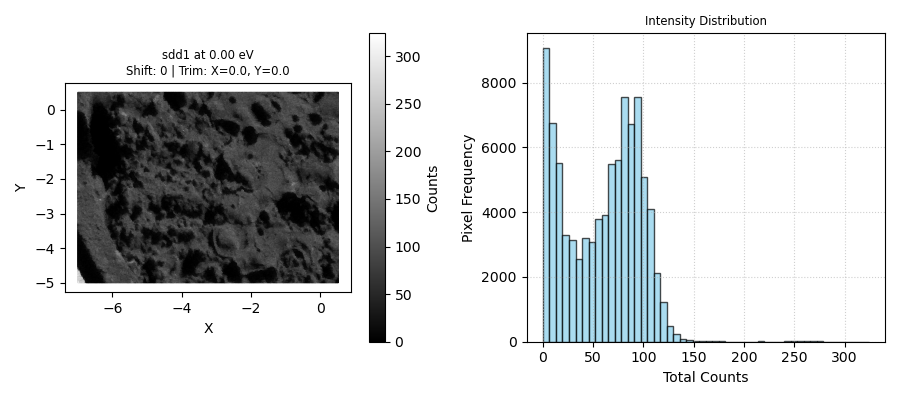

In [3]:
# Allows for the alignment of the stack to be checked
# Allows for removing some pixels ( as mm units) on the X and Y edges, which makes the stack dimensions smaller
# The new dimensions will be used in the plotting and PCA/CA
# This step can be skipped
interactive_roll_align(sgm_data, (30,50), use_color=False)

In [4]:
# Maps the fluorescence and sample TEY signal.  Can select which image for the map.
# Plots the fluorescence and TEY spectra from a stack- saves Raw and Normalized XANES spectra for each SDD, I0 and sample TEY as a csv file.
# Saves XRF spectra for each SDD as a csv file. Saves images (i.e., maps) for each SDD.
# Can change the ROI from the XRF spectrum to select the edge of interest. Each bin  about 10 eV.
# Can change the area selected on the image by dragging a rectangle or making a polygon over the area of interest. Can toggle between the two. 
# Note that the area selected will be where the spectra are derived from and saves in the csv file.
# To see the changes in the spectra need to click on the "Refresh Plots" button.
# Can use the internal I0 from the Au mesh (mcc1) or load an external I0 from a csv file for normalization- allows for which column to select
# MCC1 is the I0 from Au mesh before the KB mirrors, MCC2 is from a photodiode behind the sample (only recorded when no sample in the pathway), 
# which could be used as and Io, , MCC3 auxillary, MCC4 is TEY signal from the sample. 
# Can either show lines with or withput individual data points
# Can zoom in on spectra using tools on left.   
# Mouse over an image or plot and get the X and Y coordinates.
# Automatically adjusts the contrast for each image.  
# Plot as a scatter map (usual way) or as a heatmap.
# The default ROI on the XRF spectra is 0-255.  Drag left and right edges on the XRF spectra to select the ROI for the element of interest.
# Each bin is about 10 eV. 
# Calibrate the energy by adding an energy shift value - energy_shift = 0 as default.
# To add detailed information to the header change use_full_metadata = True.
# Can display spectra with the data points or not- show_markers = False spectra plotted without data points shown
# Can change the display of the images, selecting grey scale or color

plot_sgm_bsky_data(sgm_data, as_scatter_plot=True, fixed_roi=False, mcc_to_map=[4], channel_roi =[20,40], show_markers=False, mcc_channels = [1,4], energy_shift=0)
#plot_sgm_bsky_data(sgm_data, as_scatter_plot=True, use_color=False, fixed_roi=False, channel_roi =[30,50])

  [Auto Select] Defaulting to middle energy: 0.00 eV
--- SDD Stack Dashboard: Trial1-Tan4T-SW_map ---
  [Metadata] Full Headers: Disabled
  Location: D:\Data\Testing_jupyter-python-axis2000\4-quadrant_maps\stitched
  [Alignment] Roll Shift: 0 | Trim: X=0.000 mm, Y=0.000 mm
  Pass 1: Pre-loading energy dependence...


In [5]:
# Saving dataset for analysis with pyMCA
save_pymca_4d_stack_h5(sgm_data, normalize=True)

Detected Grid: 17 x 17
Energies: 182
Normalizing by Internal: mcc1...
Building stacks (XRF 3D, XANES 3D, Full 4D Hypercube)...
    -> Progress: 20/182 energies.
    -> Progress: 40/182 energies.
    -> Progress: 60/182 energies.
    -> Progress: 80/182 energies.
    -> Progress: 100/182 energies.
    -> Progress: 120/182 energies.
    -> Progress: 140/182 energies.
    -> Progress: 160/182 energies.
    -> Progress: 180/182 energies.
    -> Progress: 182/182 energies.

[SUCCESS] Multi-mode HDF5 saved to: D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca_4D.h5
1. For XRF ROI Imaging: Open 'xrf_measurement/sdd_xrf_stack_3d'
2. For XANES PCA: Open 'xanes_measurement/sdd_xanes_stack_3d' -> 'Load as 1D Stack'
3. For Full Hypercube: Open 'full_4d_measurement'


'D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca_4D.h5'

In [6]:
# Saving for PCA/CA and for pyMCA analysis
# Need to select the appropriate roi for the edge of interest
print("PyMca version", PyMca5.__version__)
saved_pymca_stack=save_pymca_stack_h5(sgm_data, channel_roi=(37,55))

PyMca version 5.9.5
    -> No map_roi provided; using full scan range.
    -> Target Export ROI: X=[3.752, 5.268], Y=[-2.900, -1.845]
    -> Using user-selected I0 for normalization: Internal: mcc1
Processing 182 energy steps for 4 detectors...
    -> Progress: 10/182 energies processed.
    -> Progress: 20/182 energies processed.
    -> Progress: 30/182 energies processed.
    -> Progress: 40/182 energies processed.
    -> Progress: 50/182 energies processed.
    -> Progress: 60/182 energies processed.
    -> Progress: 70/182 energies processed.
    -> Progress: 80/182 energies processed.
    -> Progress: 90/182 energies processed.
    -> Progress: 100/182 energies processed.
    -> Progress: 110/182 energies processed.
    -> Progress: 120/182 energies processed.
    -> Progress: 130/182 energies processed.
    -> Progress: 140/182 energies processed.
    -> Progress: 150/182 energies processed.
    -> Progress: 160/182 energies processed.
    -> Progress: 170/182 energies processed.

In [ ]:
# For single detector
# Determined the principal components for each SDD, or for the sum or average of eathe detectors
# Select the SDD and number of components.
# Displays the eigenimages and vectors

pca_results=pca_xanes_analysis(saved_pymca_stack, dataset_name ='sdd3', n_components =10)

In [ ]:
# For single detector
# Plots cluster maps and spectra for each detector and number of clusters selected
cluster_results=cluster_xanes_analysis(pca_results, dataset_name='sdd3', use_full_metadata=False,  n_clusters=7)

In [ ]:
# Allows for pixels to be exclude from the spectra
interactive_cluster_merger(cluster_results, dataset_name ='sdd3')


Running Multi-Detector PCA Analysis
Loading dataset 'sdd1' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...
    -> sdd1 stack shape: (17, 17, 182)
    -> sdd1 results saved to HDF5.
Loading dataset 'sdd2' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...
    -> sdd2 stack shape: (17, 17, 182)
    -> sdd2 results saved to HDF5.
Loading dataset 'sdd3' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...
    -> sdd3 stack shape: (17, 17, 182)
    -> sdd3 results saved to HDF5.
Loading dataset 'sdd4' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...
    -> sdd4 stack shape: (17, 17, 182)
    -> sdd4 results saved to HDF5.
Loading dataset 'average' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_


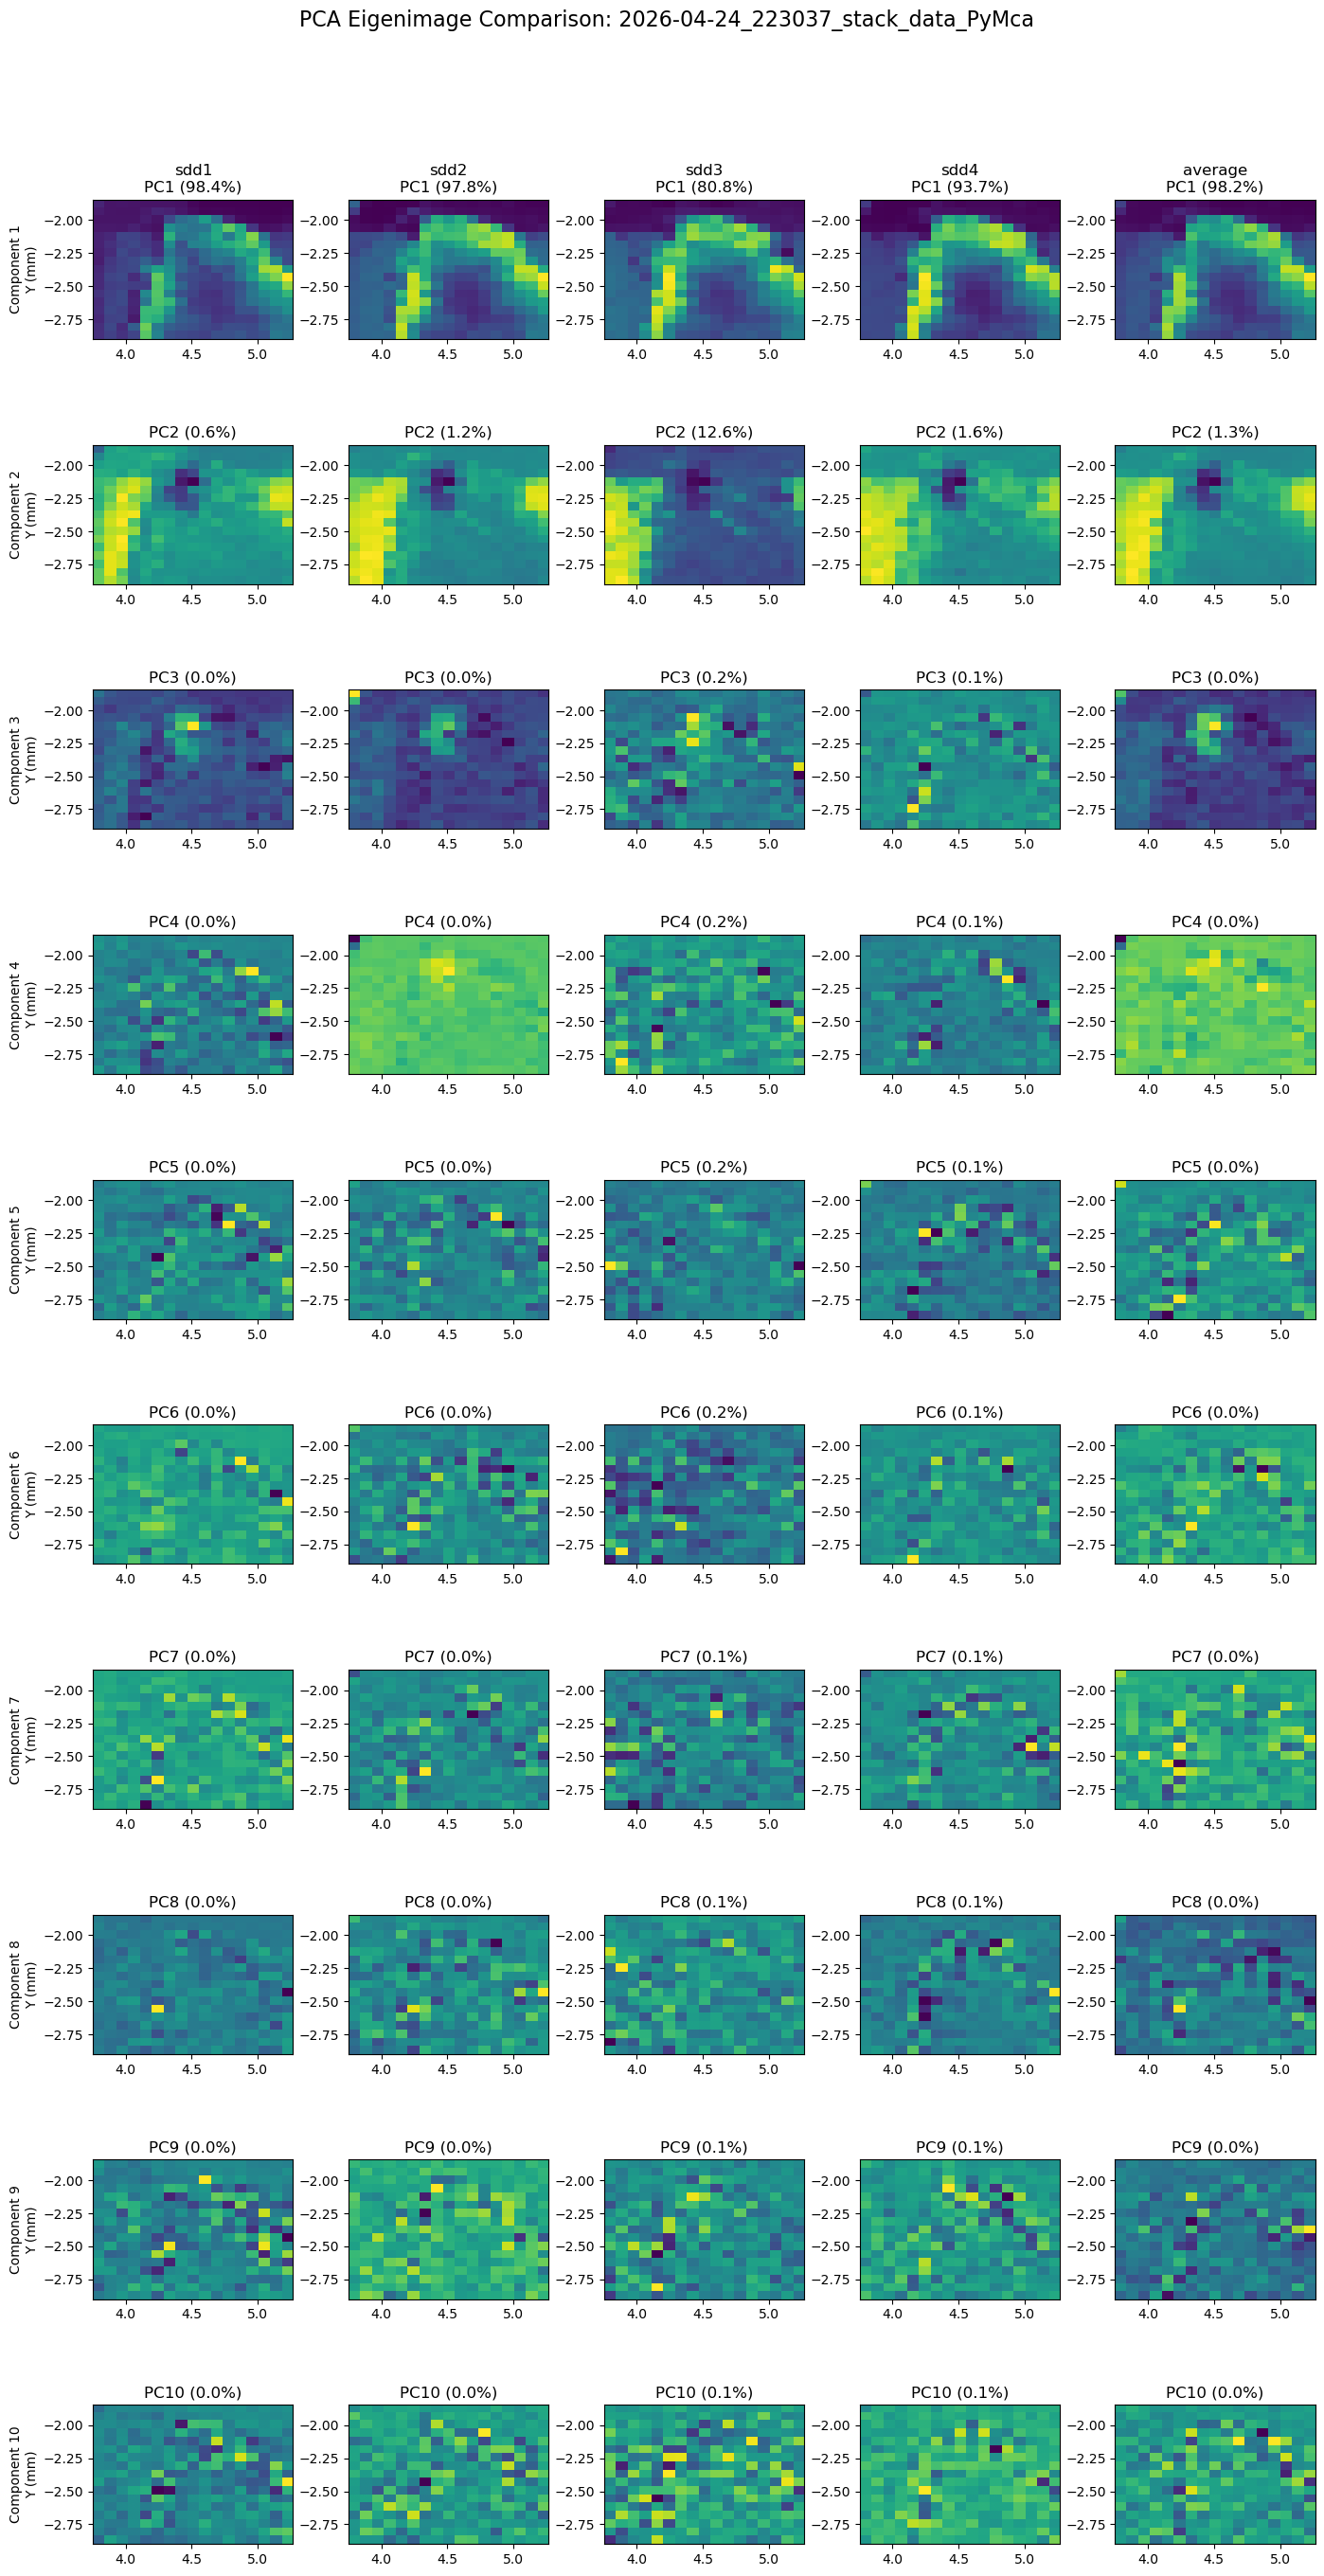


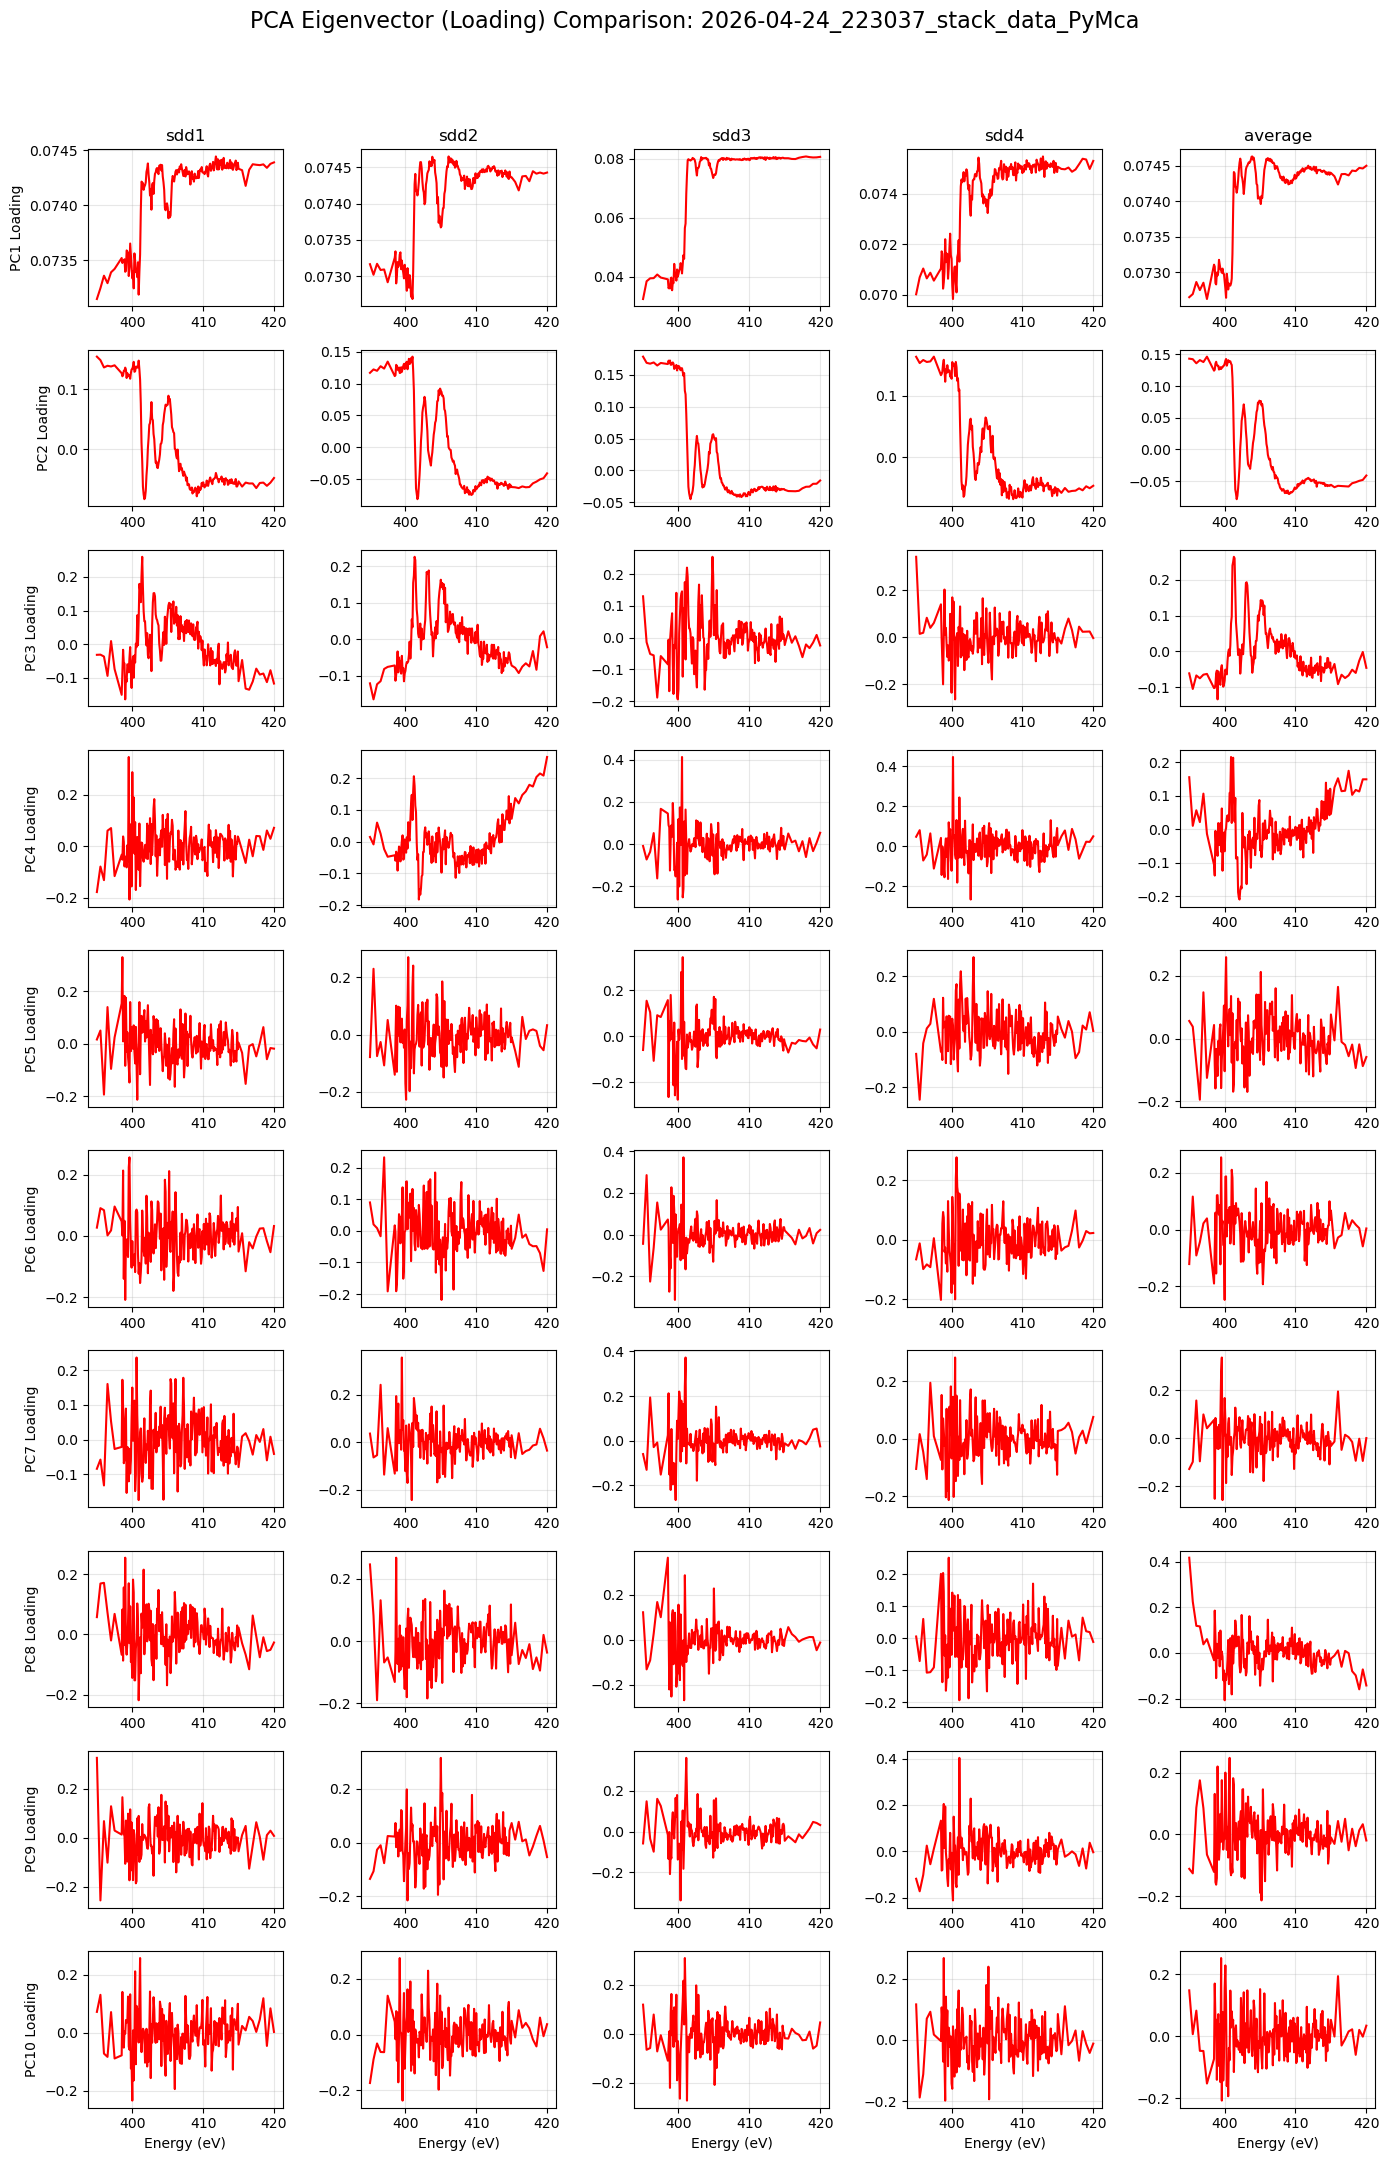

In [7]:
# For all detectors
pca_results=run_pca_all_detectors(saved_pymca_stack, n_components=10)


Running Multi-Detector Clustering Analysis
Loading PCA results for 'sdd1' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...


c:\Users\dynesj\AppData\Local\miniforge3\envs\gemini_cli2\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\dynesj\AppData\Local\miniforge3\envs\gemini_cli2\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\dynesj\AppData\Local\miniforge3\envs\gemini_cli2\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

    -> sdd1 cluster results saved.
Loading PCA results for 'sdd2' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...
    -> sdd2 cluster results saved.
Loading PCA results for 'sdd3' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...


c:\Users\dynesj\AppData\Local\miniforge3\envs\gemini_cli2\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\dynesj\AppData\Local\miniforge3\envs\gemini_cli2\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


    -> sdd3 cluster results saved.
Loading PCA results for 'sdd4' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...
    -> sdd4 cluster results saved.
Loading PCA results for 'average' from D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack/2026-04-24_223037_stack_data_PyMca.h5...


c:\Users\dynesj\AppData\Local\miniforge3\envs\gemini_cli2\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


    -> average cluster results saved.

Multi-detector clustering plots saved to:
  -> D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack\2026-04-24_223037_stack_data_PyMca_cluster_comparison_maps.png
  -> D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack\2026-04-24_223037_stack_data_PyMca_cluster_comparison_spectra.png



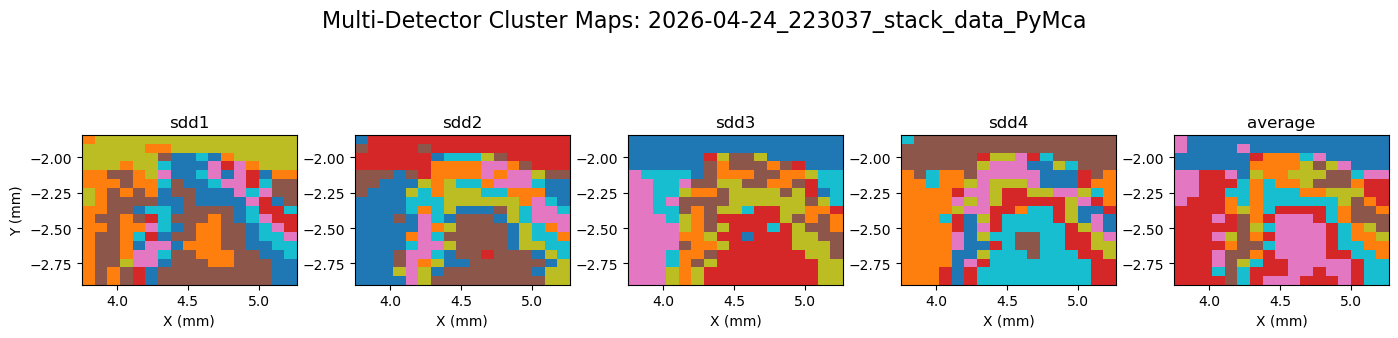


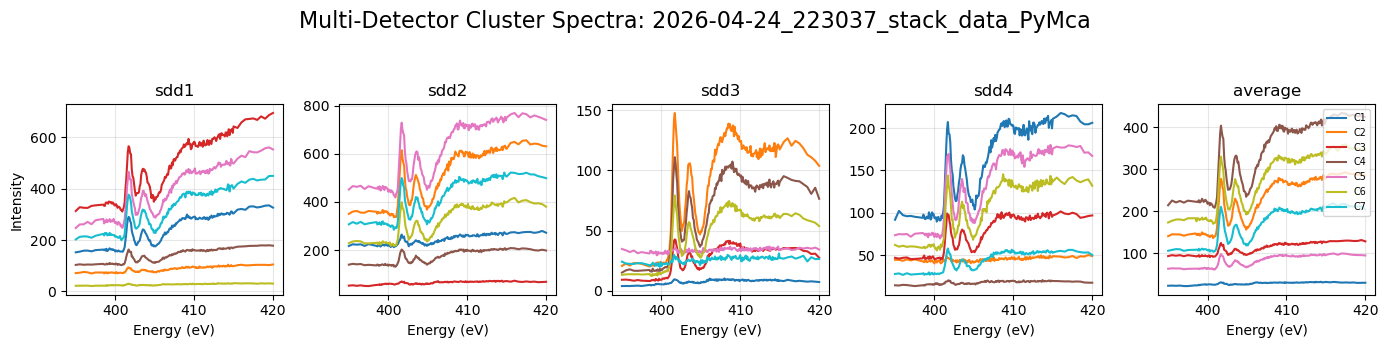

    -> Combined cluster sums saved to: D:/Data/Testing_jupyter-python-axis2000/N_stacks/223029_Au13_0013_n1s_stack\2026-04-24_223037_stack_data_PyMca_all_detectors_cluster_sums.csv


In [7]:
# For all detectors
cluster_results=run_clustering_all_detectors(pca_results, use_full_metadata=False, n_clusters=7)

VBox()

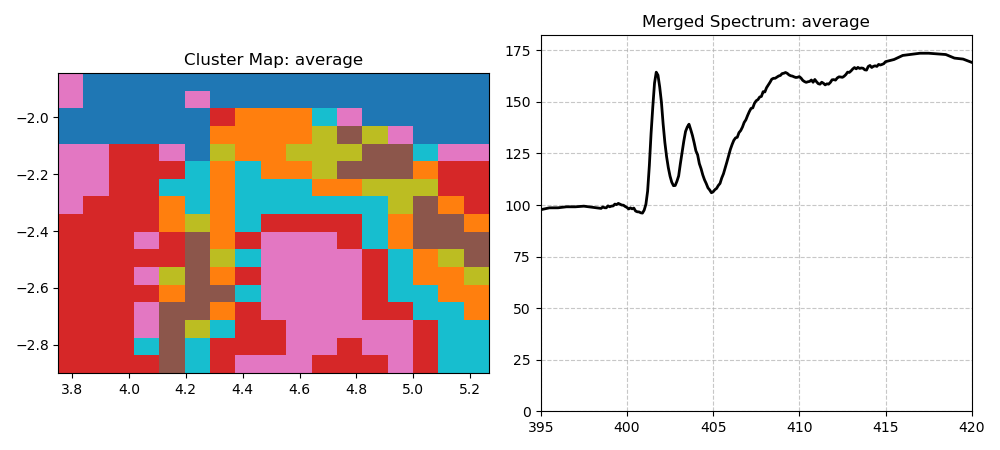

In [18]:
#For all detectors
interactive_cluster_merger(cluster_results)

In [5]:
# Adds the I0 from the Au mesh (mcc1) from a number of  N1s spectra
# The reason is to increase the S/N ratio of the I0, thus increasing the S/N of the normalized spectrum
sum_mcc1_spectra()

Loading 2026-04-24_223037_stack_data.h5...
Loading 2026-04-24_233217_stack_data.h5...
Loading 2026-04-24_205859_stack_data.h5...
Loading 2026-04-24_195642_stack_data.h5...
Loading 2026-04-24_182915_stack_data.h5...

[SAVE SUCCESS] MCC1 Average saved to:
--> D:\Data\Testing_jupyter-python-axis2000\N_stacks\223029_Au13_0013_n1s_stack\test1-all.csv

[SAVE SUCCESS] MCC1 Average saved to:
--> D:\Data\Testing_jupyter-python-axis2000\N_stacks\223029_Au13_0013_n1s_stack\test2-removed.csv
